# BÀI TẬP PHẦN 1: CÁC THUẬT TOÁN TÌM KIẾM TRÊN ĐỒ THỊ

**Họ tên:** Nguyễn Ngọc Hải

**MSSV:** 24880218

## Hướng dẫn
Phần này yêu cầu bạn cài đặt các thuật toán tìm kiếm cơ bản (BFS, DFS, Greedy BFS, UCS, A*) trên cấu trúc dữ liệu đồ thị dạng danh sách kề.

**Yêu cầu:**
1. **Phiên bản Tiêu chuẩn:** Chỉ sử dụng `list` cơ bản của Python. Không dùng `heapq`, `deque`. Với Priority Queue, phải duyệt danh sách để tìm phần tử nhỏ nhất.
2. **Phiên bản Tối ưu (Optimized):** Sử dụng các cấu trúc dữ liệu hiệu quả (`collections.deque` cho Queue, `heapq` cho Priority Queue).

**Lưu ý quan trọng:**
- Bạn cần có file `graph.txt` nằm cùng thư mục với notebook này để chạy code.
- Các cell kiểm tra (Judge Cells) và cell Benchmarking sẽ **đọc trực tiếp dữ liệu từ file `graph.txt`** bằng hàm `read_graph_input` của bạn.
- **Tie-breaking:** Nếu giá trị ưu tiên bằng nhau, hãy chọn đỉnh có **index nhỏ hơn**.
- Đảm bảo hàm tìm kiếm trả về `None` nếu không tìm thấy đường đi.

In [1]:
import sys
import time
import heapq
import os
from collections import deque
import matplotlib.pyplot as plt 
%matplotlib inline

### 1.0. Hàm đọc input

Cài đặt hàm đọc đồ thị từ file.
**Format file:**
- Dòng 1: `n m` (số đỉnh, số cạnh)
- Dòng 2: `h0 h1 ... hn-1` (heuristics)
- m dòng sau: `u v w` (cạnh u->v trọng số w)

**Ví dụ:**

```text
4 5
7 2 1 0
0 1 1
0 2 4
1 2 2
1 3 5
2 3 1
```

In [2]:
def read_graph_input(file_path):
    """
    Đọc đồ thị từ file_path.
    Trả về: (graph, heuristics, start, goal)
    graph: Dictionary {u: [(v, w), ...]}
    heuristics: List [h0, h1, ...]
    start: 0
    goal: n-1
    """
    # YOUR CODE HERE
    # Mở file
    with open(file_path, "r", encoding="utf-8") as f:
        # Đọc dòng 1 trong file để lấy giá trị n và m
        n, m = map(int, (f.readline().split()))

        # Set giá trị cho start và goal
        start, goal = 0, n - 1

        # Khởi tạo dictionary graph có các value là empty list cho các đỉnh trong graph
        graph = {u: [] for u in range(n)}

        # Đọc dòng 2 trong file để lấy list heuristic
        heuristics = list(map(int, f.readline().split()))

        # Loop qua toàn bộ các dòng còn lại trong file
        for line in f:
            # Tách line đọc được thành list các word
            temp = line.split()
            # Kiểm tra nếu line là 1 dòng trống
            if not temp:
                continue
            # Đọc line và tách lấy 3 giá trị u, v, w
            u, v, w = map(int, temp)
            # Append vào list value của đỉnh key tương ứng
            graph[u].append((v, w))

    # Return kết quả
    return graph, heuristics, start, goal

graph, heuristics, start, goal = read_graph_input("graph.txt")

## 1.a. Cài đặt thuật toán Tiêu chuẩn

Trong phần này, bạn **KHÔNG ĐƯỢC** sử dụng `collections.deque` hay `heapq`. Bạn chỉ được dùng `list` của Python.
- **Queue (BFS):** Dùng `list`, lấy phần tử đầu bằng `.pop(0)`.
- **Priority Queue (Greedy, UCS, A*):** Dùng `list`, mỗi lần cần lấy phần tử nhỏ nhất thì duyệt toàn bộ list để tìm (Linear Scan).
- **Tie-break:** Nếu giá trị so sánh bằng nhau, ưu tiên đỉnh có index nhỏ hơn.

In [3]:
def bfs(graph, start, goal):
    """BFS sử dụng list làm queue (pop(0))."""
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    # Dict trace dùng để search ngược đường đi
    trace = dict()
    # Add Start vào queue
    queue = [start]
    # Sử dụng set để tăng tốc độ search so với list
    # Set visited dùng để đánh dấu các đỉnh đã nhìn thấy (bao gồm đã duyệt)
    visited = {start}

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]  

    # Loop đến khi queue rỗng
    while queue:        
        # Lấy đỉnh đầu queue ra khỏi queue (FIFO)
        u = queue.pop(0)

        # Loop qua từng cặp đỉnh kề và trọng số
        # Thực hiện sorted graph để đảm bảo index tăng dần
        for v, _ in sorted(graph[u]):
            # Kiểm tra nếu v đã xuất hiện rồi thì bỏ qua
            if v in visited:
                continue
            # Thêm đỉnh v vào queue và visited
            queue.append(v)
            visited.add(v)
            # Tạo một key, value trong trace dict để đánh dấu đỉnh v do đỉnh u đi tới
            trace[v] = u

            # Dừng nếu nhìn thấy goal
            if v == goal:
                return get_path()

    # Không tìm thấy path trả về None
    return None

bfs(graph, start, goal)

def dfs(graph, start, goal):
    """DFS sử dụng list làm stack."""
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    # Khởi tạo
    trace = {}       # Dict dùng để trace back tạo path
    visited = set()  # Set đánh dấu các node đã visit 
    stack = [start]  # stack để duyệt DFS

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]    

    # Loop đến khi stack empty
    while stack:
        # Lấy node ở đỉnh stack
        u = stack.pop()

        # Node đã visit rồi -> bỏ qua, vì chỉ có 2 trường hợp:
        # TH1: Node không dẫn đến goal -> visit lại cũng không đến goal
        # TH2: Node có thể dẫn đến goal, nhưng cần phải đi qua node con khác 
        #      -> chỉ cần thăm các node con chưa xuất hiện trong visited thôi
        if u in visited:
            continue

        # Đánh dấu node đã visit
        visited.add(u)

        # Nếu là goal thì dừng và trả về path
        if u == goal:
            return get_path()

        # Từ node đang duyệt, add các node kề vào stack với điều kiện node index nhỏ nằm ở đỉnh stack
        for v, _ in sorted(graph[u], reverse=True):
            if v not in visited:
                stack.append(v)
                # Tạo cặp node: node cha, trong dict
                trace[v] = u

    # Không tim thấy path -> Return None
    return None

def greedy_best_first_search(graph, heuristics, start, goal):
    """Greedy Best-First Search tự tìm min trong list."""
    # YOUR CODE HERE
    # Kiểm tra nếu goal cũng là start
    if start == goal: return [start]

    pq = [start]           # Priority Queue
    trace = {start: None}  # Dict để truy vết đường đi

    def pop_min_queue():
        """Hàm pop phần tử có heuristic nhỏ nhất trong priority queue"""
        min_node = pq[0]
        min_index = 0
        min_h = heuristics[min_node]
        for idx, node in enumerate(pq):
            current_h = heuristics[node]
            if (current_h < min_h) or \
               (current_h == min_h and node < min_node):
                min_node = node
                min_index = idx
                min_h = current_h

        return pq.pop(min_index)

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Priority Queue empty
    while pq:
        # Lấy đỉnh có heuristic nhỏ nhất ra khỏi Priority Queue
        node = pop_min_queue()
        # Kiểm tra nếu tìm thấy goal
        if node == goal:
            return get_path()

        # Mở rộng từ node đang duyệt theo greedy
        for v, _ in graph[node]:
            # Nếu v chưa từng được duyệt thì thêm vào trace
            if v not in trace:
                pq.append(v)
                trace[v] = node

    # Không tìm thấy đường đi
    return None

def ucs(graph, start, goal):
    """Uniform Cost Search tự tìm min cost trong list."""
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    pq = [start]            # Priority Queue của UCS
    cost_dict = {start: 0}  # Cost dict để lưu giá trị node và cost tương ứng
    trace = {}              # Trace dict để truy vết ngược tạo path
    visited = set()         # Set đánh dấu các node đã duyệt

    def pop_min_queue() -> int:
        """Hàm trả về node có tổng trọng số nhỏ nhất trong Priority Queue"""
        min_node = pq[0]
        min_cost = cost_dict[min_node]
        min_index = 0
        # Tìm node có cost thấp nhất trong Priority Queue
        for idx, node in enumerate(pq):
            current_cost = cost_dict[node]
            if (current_cost < min_cost) or \
               (current_cost == min_cost and node < min_node):
                min_node  = node
                min_index = idx
                min_cost  = current_cost

        return pq.pop(min_index)

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Priority Queue empty
    while pq:
        node = pop_min_queue()  # Lấy node có cost thấp nhất khỏi Priority Queue
        g = cost_dict[node]     # Lấy cost hiện tại
        visited.add(node)       # Đánh dấu node đã duyệt

        # Dừng nếu tìm thấy goal
        if node == goal:
            return get_path()

        # Mở rộng Priority Queue từ node đang duyệt
        for v, w in graph[node]:
            # Bỏ qua các node đã duyệt
            if v in visited:
                continue
            # Tính cost từ node đang duyệt tới node mở rộng được
            new_cost = g + w
            # Kiểm tra node có trong cost_dict chưa 
            # Nếu có == có trong Priority Queue luôn
            if v in cost_dict:
                # Update giá trị cost nếu cost tốt hơn
                if cost_dict[v] > new_cost:
                    cost_dict[v] = new_cost
                    trace[v] = node
            else:
                # Chưa có thì thêm mới
                pq.append(v)
                cost_dict[v] = new_cost
                trace[v] = node

    # Không tìm thấy path -> Trả về None
    return None

def a_star(graph, heuristics, start, goal):
    """A* tự tìm min f trong list."""
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    pq = [start]            # Priority Queue của A*
    trace = {}              # Trace dict để truy vết ngược tạo path
    cost_dict = {start: heuristics[start]}  # Cost dict để lưu giá trị node và f tương ứng

    def pop_min_queue() -> int:
        """Hàm trả về node có f nhỏ nhất trong Priority Queue"""
        min_node = pq[0]
        f_min = cost_dict[min_node]
        min_index = 0
        # Tìm node có f nhỏ nhất trong Priority Queue
        for idx, node in enumerate(pq):
            f = cost_dict[node]
            if (f < f_min) or \
               (f == f_min and node < min_node):
                min_node  = node
                min_index = idx
                f_min     = f

        return pq.pop(min_index)

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Priority Queue empty
    while pq:
        node = pop_min_queue()                  # Lấy node có f nhỏ nhất khỏi Priority Queue
        g = cost_dict[node] - heuristics[node]  # Lấy trọng số hiện tại g = f - h

        # Dừng nếu tìm thấy goal
        if node == goal:
            return get_path()

        # Mở rộng Priority Queue từ node đang duyệt
        for v, w in graph[node]:
            # Tính f từ node đang duyệt tới node mở rộng được f = g + w + h
            f = g + w + heuristics[v]
            # Kiểm tra node có trong cost_dict chưa
            if v in cost_dict:
                # Update giá trị f nếu f hiện tại tốt hơn
                if cost_dict[v] > f:
                    cost_dict[v] = f
                    trace[v] = node
                    # Add v lại nếu v đã pop ra khỏi Priority Queue
                    if v not in pq:
                        pq.append(v)
            else:
                # Chưa có thì thêm mới
                pq.append(v)
                cost_dict[v] = f
                trace[v] = node

    # Không tìm thấy path -> Trả về None
    return None

In [4]:
# TEST CELL: BFS Standard (5 points)
print(bfs(graph, start, goal))

[0, 1, 296, 999]


In [5]:
# TEST CELL: DFS Standard (5 points)
print(dfs(graph, start, goal))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [6]:
# TEST CELL: Greedy Standard (5 points)
greedy_best_first_search(graph, heuristics, start, goal)

[0, 295, 463, 464, 649, 789, 999]

In [7]:
# TEST CELL: UCS Standard (5 points)
print(ucs(graph, start, goal))

[0, 846, 857, 999]


In [8]:
# TEST CELL: A* Standard (5 points)
print(a_star(graph, heuristics, start, goal))

[0, 846, 857, 999]


### 1.2. Cài đặt thuật toán Tối ưu (Optimized)

Trong phần này, hãy cải thiện hiệu năng bằng cách sử dụng:
- `collections.deque` cho BFS.
- `heapq` cho Greedy, UCS, và A*.

Tên hàm sẽ có hậu tố `_optimized`.

In [9]:
def bfs_optimized(graph, start, goal):
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    queue = deque([start])
    trace = dict()
    visited = {start}

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Queue empty
    while queue:
        # FIFO: lấy node đầu queue ra
        node = queue.popleft()

        # Mở rộng queue từ node đang duyệt, theo node index tăng dần
        for v, _ in sorted(graph[node]):
            # Bỏ qua node đã duyệt
            if v in visited:
                continue
            # Update trace dict
            trace[v] = node
            # Nhìn thấy goal
            if v == goal:
                return get_path()
            visited.add(v)   # Đánh dấu đã duyệt
            queue.append(v)  # Enqueue

    # Không tìm được path -> Trả về None
    return None

def dfs_optimized(graph, start, goal):
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    stack = deque([start])
    trace = dict()
    visited = set()

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Stack empty
    while stack:
        # Lấy node đỉnh stack
        node = stack.pop()
        # Bỏ qua nếu node đã duyệt
        if node in visited:
            continue
        # Đánh dấu node đã duyệt
        visited.add(node)
        # Tìm thấy goal thì dừng
        if node == goal:
            return get_path()        

        # Mở rộng stack từ node đang duyệt
        for v, _ in sorted(graph[node], reverse=True):
            if v not in visited:
                trace[v] = node
                # Push node vào stack
                stack.append(v)

    # Không tìm thấy path -> Trả về None
    return None

def greedy_optimized(graph, heuristics, start, goal):
    # YOUR CODE HERE
    # Kiểm tra nếu goal cũng là start
    if start == goal: return [start]

    pq = [(heuristics[start], start)]  # Priority Queue theo min heap
    trace = {start: None}              # Dict để truy vết đường đi

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Priority Queue empty
    while pq:
        # Priority Queue hoạt động theo min heap nên heappop lấy giá trị min
        _, node = heapq.heappop(pq)
        # Kiểm tra nếu tìm thấy goal
        if node == goal:
            return get_path()

        # Mở rộng từ node đang duyệt theo greedy
        for v, _ in graph[node]:
            # Nếu v chưa được đưa vào priority queue
            if v not in trace:
                # heappush dùng giá trị heuristic để so sánh
                # Nếu heuristic bằng nhau, node có index nhỏ sẽ được tính là min vì là min heap
                heapq.heappush(pq, (heuristics[v], v))
                trace[v] = node

    # Không tìm thấy đường đi
    return None

def ucs_optimized(graph, start, goal):
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    pq = [(0, start)]       # Priority Queue của UCS theo min heap
    trace = {start: None}   # Trace dict để truy vết ngược tạo path
    cost_dict = {start: 0}  # Cost dict để lưu giá trị node và cost tương ứng
    visited = set()         # Set đánh dấu các node đã duyệt

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Priority Queue empty
    while pq:
        g, node = heapq.heappop(pq)  # Lấy node có g thấp nhất khỏi Priority Queue

        # Trường hợp cùng 1 node nhưng khác trọng số thì trọng số nhỏ sẽ được pop trước
        # Sau đó khi gặp lại node đấy, sẽ bỏ qua vì đã duyệt
        if node in visited:
            continue
        
        visited.add(node)

        # Dừng nếu tìm thấy goal
        if node == goal:
            return get_path()

        # Mở rộng Priority Queue từ node đang duyệt
        for v, w in graph[node]:
            # Bỏ qua các node đã duyệt
            if v not in visited:
                # Tính cost từ node đang duyệt tới node mở rộng được
                new_cost = g + w
                # Node đã trong Priority Queue nhưng trọng số kém hơn, bỏ qua
                if v in trace and cost_dict[v] <= new_cost:
                    continue

                trace[v] = node                    # Cập nhật node cha
                cost_dict[v] = new_cost            # Cập nhật trọng số
                heapq.heappush(pq, (new_cost, v))  # Push vào Priority Queue theo min heap

    # Không tìm thấy path -> Trả về None
    return None

def astar_optimized(graph, heuristics, start, goal):
    # YOUR CODE HERE
    # Kiểm tra nếu start cũng là goal
    if start == goal: return [start]

    pq = [(heuristics[start], start)]       # Priority Queue của A*
    trace = {}                              # Trace dict để truy vết ngược tạo path
    cost_dict = {start: heuristics[start]}  # Cost dict để lưu giá trị node và f tương ứng

    def get_path() -> list:
        """Hàm trả về path từ start đến goal"""
        path = [goal]
        while path[-1] != start:
            path.append(trace[path[-1]])
        return path[::-1]

    # Loop đến khi Priority Queue empty
    while pq:
        # Lấy node có f nhỏ nhất khỏi Priority Queue
        f, node = heapq.heappop(pq)

        # Bỏ qua phần tử đã được pop ra với giá trị tốt hơn
        # Lý do: đỉnh luôn được push lại vào min heap khi tìm được f tốt hơn chứ không replace
        # Nên khi pop ra có thể xảy ra trường hợp pop được đỉnh có f cũ (cao hơn)
        if f > cost_dict[node]:
            continue
        # Lấy trọng số hiện tại g = f - h
        g = f - heuristics[node]

        # Dừng nếu tìm thấy goal
        if node == goal:
            return get_path()

        # Mở rộng Priority Queue từ node đang duyệt
        for v, w in graph[node]:
            # Tính f từ node đang duyệt tới node mở rộng được f = g + w + h
            f = g + w + heuristics[v]
            # Bỏ qua đã có đường tới v với f tốt hơn
            if v in cost_dict and cost_dict[v] <= f:
                continue
            
            heapq.heappush(pq, (f, v))  # Push vào Priority Queue
            cost_dict[v] = f            # Cập nhật cost_dict với f tốt nhất hiện tại
            trace[v] = node             # Cập nhật node cha tạo ra f tốt nhất

    # Không tìm thấy path -> Trả về None
    return None

In [10]:
# TEST CELL: BFS Optimized (5 points)
print(bfs_optimized(graph, start, goal))

[0, 1, 296, 999]


In [11]:
# TEST CELL: DFS Optimized (5 points)
print(dfs_optimized(graph, start, goal))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221,

In [12]:
# TEST CELL: Greedy Optimized (5 points)
print(greedy_optimized(graph, heuristics, start, goal))

[0, 295, 463, 464, 649, 789, 999]


In [13]:
# TEST CELL: UCS Optimized (5 points)
print(ucs(graph, start, goal))

[0, 846, 857, 999]


In [14]:
# TEST CELL: A* Optimized (5 points)
print(astar_optimized(graph, heuristics, start, goal))

[0, 846, 857, 999]


### 1.3. So sánh hiệu năng (Benchmarking)

Code dưới đây sẽ so sánh thời gian chạy giữa phiên bản **Tiêu chuẩn** và **Tối ưu** trên dữ liệu đọc từ `./graph.txt`.

Algorithm  | Standard (s) | Optimized (s) | Improvement 
-------------------------------------------------------
BFS        | 0.000124     | 0.000098     | 1.27x
DFS        | 0.004201     | 0.003815     | 1.10x
Greedy     | 0.000602     | 0.000202     | 2.98x
UCS        | 0.000714     | 0.000224     | 3.18x
A*         | 0.000178     | 0.000087     | 2.05x


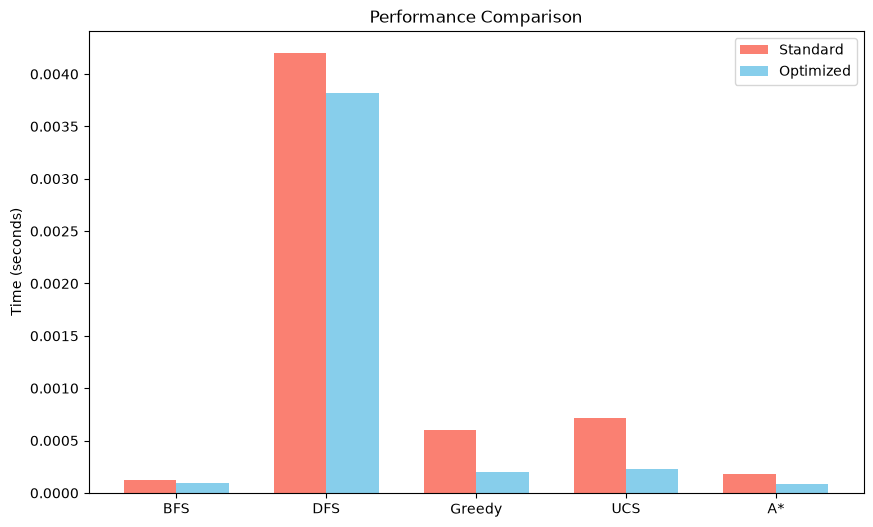

In [15]:
def benchmark_algorithms():
    try:
        graph, heuristics, start, goal = read_graph_input('./graph.txt')
    except FileNotFoundError:
        print("Lỗi: Không tìm thấy file './graph.txt'. Vui lòng tạo file này để chạy benchmark.")
        return

    # (Algorithm Name, Std Func, Optimized Func, Arguments)
    algos = [
        ("BFS", bfs, bfs_optimized, (graph, start, goal)),
        ("DFS", dfs, dfs_optimized, (graph, start, goal)),
        ("Greedy", greedy_best_first_search, greedy_optimized, (graph, heuristics, start, goal)),
        ("UCS", ucs, ucs_optimized, (graph, start, goal)),
        ("A*", a_star, astar_optimized, (graph, heuristics, start, goal))
    ]
    
    labels = []
    t_std = []
    t_opt = []
    
    print(f"{'Algorithm':<10} | {'Standard (s)':<12} | {'Optimized (s)':<12} | {'Improvement':<12}")
    print("-"*55)

    for name, s_func, o_func, args in algos:
        try:
            # Standard
            st = time.time()
            s_func(*args)
            ts = time.time() - st
            
            # Optimized
            st = time.time()
            o_func(*args)
            to = time.time() - st
            
            labels.append(name)
            t_std.append(ts)
            t_opt.append(to)
            
            improv = ts / to if to > 0 else 0
            print(f"{name:<10} | {ts:.6f}     | {to:.6f}     | {improv:.2f}x")
            
        except Exception as e:
            print(f"{name:<10} | Error: {e}")

    if labels:
        x = range(len(labels))
        width = 0.35
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.bar([i - width/2 for i in x], t_std, width, label='Standard', color='salmon')
        ax.bar([i + width/2 for i in x], t_opt, width, label='Optimized', color='skyblue')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel('Time (seconds)')
        ax.set_title('Performance Comparison')
        ax.legend()
        plt.show()

benchmark_algorithms()

### Câu hỏi lý thuyết (10 điểm)
So sánh ưu nhược điểm của BFS và DFS trong trường hợp đồ thị vô hạn hoặc rất lớn.

Câu trả lời:

YOUR ANSWER HERE